In [1]:
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
data_path = os.getenv("DATA_PATH")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv(data_path)

df.replace("?", np.nan, inplace=True)

for col in ['workclass', 'occupation', 'native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

In [5]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Remove target column (unsupervised learning)
X = df_encoded.drop("income", axis=1)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [12]:
print(X_pca)

[[-1.18066609  0.8920609 ]
 [-0.2518533   0.77134124]
 [ 0.63159863  2.05955509]
 ...
 [-0.94558677 -0.44197521]
 [ 1.93370768  0.57514722]
 [ 1.60252027 -0.09329179]]


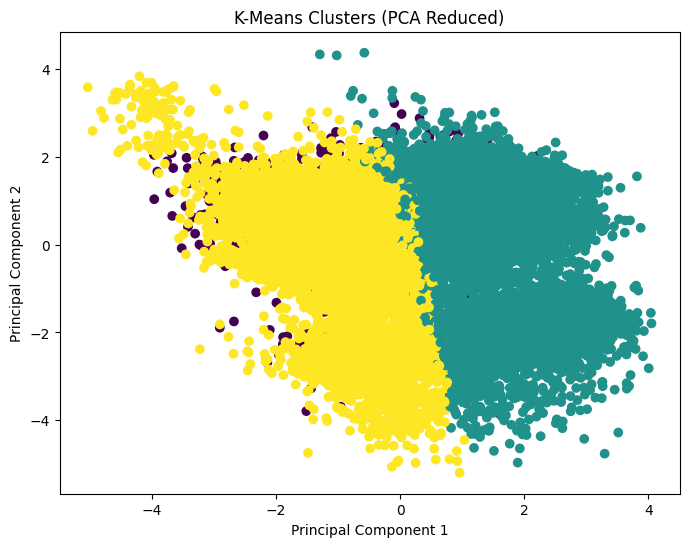

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

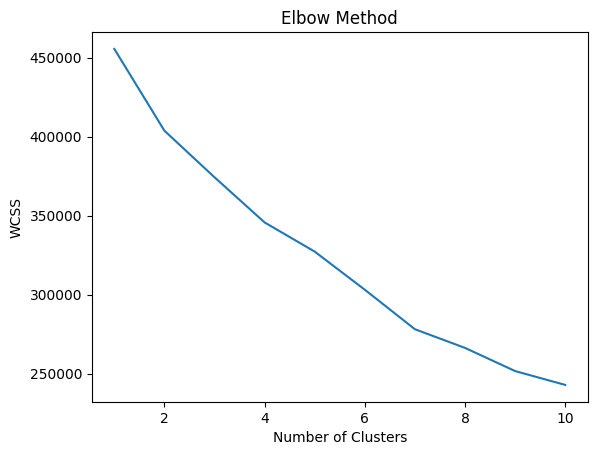

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()